In [ ]:
print("test")

# Temas 6 y 7 - Amplificación y Amplificador Operacional

**Fundamentos de Electrónica - 2º GIERM**

---

## Objetivos de aprendizaje

- Comprender el concepto de amplificación y los cuatro modelos de amplificador (tensión, corriente, transconductancia, transresistencia)
- Dominar las definiciones de ganancia en tensión, corriente, potencia y decibelios
- Conocer los efectos capacitivos sobre la ganancia y los diagramas de Bode
- Entender el amplificador diferencial y las propiedades del OPAM ideal
- Resolver circuitos con las configuraciones fundamentales del OPAM (inversor, no inversor, sumador, diferenciador, integrador)
- Analizar el trigger de Schmitt y comprender las limitaciones del OPAM real (GBW, slew rate, saturación)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales, datos
COLOR_RECTA = '#cb181d'       # rojo - rectas de carga, límites, saturación
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados OK
COLOR_N = '#a6cee3'           # azul claro
COLOR_P = '#b2df8a'           # verde claro

print('Configuración lista.')

Configuración lista.


---

# PARTE 1: Amplificación (Tema 6)

---

## 1. Introducción: ¿Qué es la amplificación?

Un **amplificador** es un dispositivo que toma una señal de entrada (pequeña) y produce una señal de salida más grande, manteniendo la forma de onda. Es una **bipuerta** (red de dos puertos): un puerto de entrada y un puerto de salida.

**Analogía:** Piensa en un micrófono y un altavoz. La voz (señal débil) entra por el micrófono, el amplificador aumenta la señal, y el altavoz reproduce el sonido amplificado. La energía extra proviene de la fuente de alimentación.

**Características clave:**
- La señal de salida es una versión amplificada (o atenuada) de la entrada
- La energía adicional proviene de la fuente de alimentación (no se crea de la nada)
- Un amplificador se modela como una **bipuerta lineal** con parámetros: ganancia, impedancia de entrada, impedancia de salida

---

## 2. Definiciones de ganancia

### 2.1 Ganancia en tensión, corriente y potencia

$$\boxed{A_v = \frac{V_o}{V_i}} \qquad \boxed{A_i = \frac{I_o}{I_i}} \qquad \boxed{A_p = \frac{V_o \cdot I_o}{V_i \cdot I_i} = A_v \cdot A_i}$$

- $A_v$: **ganancia de tensión** (adimensional)
- $A_i$: **ganancia de corriente** (adimensional)
- $A_p$: **ganancia de potencia** (adimensional)

### 2.2 Decibelios (dB)

Los decibelios permiten trabajar con **sumas en lugar de productos** cuando se encadenan amplificadores.

$$\boxed{A_{p_{\text{dB}}} = 10 \cdot \log_{10}(A_p)}$$

$$\boxed{A_{v_{\text{dB}}} = 20 \cdot \log_{10}(|A_v|)} \qquad \boxed{A_{i_{\text{dB}}} = 20 \cdot \log_{10}(|A_i|)}$$

**Tabla de valores comunes en dB:**

| $A_v$ (lineal) | $A_{v_{\text{dB}}}$ | Interpretación |
|:---:|:---:|:---|
| 1 | 0 dB | Sin amplificación |
| 2 | 6 dB | Doble de tensión |
| 10 | 20 dB | 10 veces la tensión |
| 100 | 40 dB | 100 veces la tensión |
| 1000 | 60 dB | 1000 veces la tensión |
| $1/\sqrt{2} \approx 0.707$ | -3 dB | **Frecuencia de corte** (mitad de potencia) |
| 0.1 | -20 dB | Atenuación a 1/10 |

**Truco para el examen:** Amplificadores en cascada $\to$ las ganancias en dB se **suman**:
$$A_{v_{\text{total, dB}}} = A_{v_1\text{dB}} + A_{v_2\text{dB}} + \cdots$$

---

## 3. Modelado de fuente y carga

### 3.1 Modelos de fuente

La fuente de señal se puede modelar de dos formas equivalentes:

| Modelo | Componentes | Esquema |
|:---|:---|:---|
| **Thévenin** | $V_s$ (fuente de tensión) en serie con $R_s$ | Fuente de tensión + resistencia serie |
| **Norton** | $I_s = V_s/R_s$ (fuente de corriente) en paralelo con $R_p = R_s$ | Fuente de corriente + resistencia paralelo |

### 3.2 Modelo de carga

La carga se modela simplemente como una **impedancia** $Z_L$ (en DC, una resistencia $R_L$). La carga afecta directamente a la ganancia real del amplificador, ya que forma un divisor de tensión con la resistencia de salida $R_o$.

---

## 4. Circuitos equivalentes del amplificador

Existen **cuatro modelos** de amplificador según el tipo de variable de entrada y salida:

### 4.1 Amplificador de tensión

| Parámetro | Descripción |
|:---|:---|
| $A_{vo}$ | Ganancia de tensión en vacío (circuito abierto) |
| $R_i$ | Resistencia de entrada |
| $R_o$ | Resistencia de salida |

$$\boxed{A_v = A_{vo} \cdot \frac{R_L}{R_o + R_L} \cdot \frac{R_i}{R_s + R_i}}$$

- **Ideal:** $R_i \to \infty$ (no carga la fuente), $R_o \to 0$ (entrega toda la tensión a la carga)
- Con $R_i \to \infty$ y $R_o \to 0$: $A_v = A_{vo}$

### 4.2 Amplificador de corriente

| Parámetro | Descripción |
|:---|:---|
| $A_{icc}$ | Ganancia de corriente en cortocircuito |
| $R_i$ | Resistencia de entrada |
| $R_o$ | Resistencia de salida |

$$\boxed{A_i = -A_{icc} \cdot \frac{R_o}{R_o + R_L} \cdot \frac{R_p}{R_p + R_i}}$$

- **Ideal:** $R_i \to 0$ (acepta toda la corriente), $R_o \to \infty$ (fuerza la corriente en la carga)

### 4.3 Amplificador de transconductancia

| Parámetro | Descripción |
|:---|:---|
| $A_{tcc}$ | Transconductancia en cortocircuito (A/V) |
| $R_i$ | Resistencia de entrada |
| $R_o$ | Resistencia de salida |

- Entrada: tensión $\to$ Salida: corriente
- **Ideal:** $R_i \to \infty$, $R_o \to \infty$

### 4.4 Amplificador de transresistencia

| Parámetro | Descripción |
|:---|:---|
| $A_{ro}$ | Transresistencia en circuito abierto (V/A) |
| $R_i$ | Resistencia de entrada |
| $R_o$ | Resistencia de salida |

- Entrada: corriente $\to$ Salida: tensión
- **Ideal:** $R_i \to 0$, $R_o \to 0$

### Tabla resumen de los 4 modelos

| Modelo | Entrada | Salida | $R_i$ ideal | $R_o$ ideal | Ganancia |
|:---|:---:|:---:|:---:|:---:|:---|
| Tensión | $V$ | $V$ | $\infty$ | $0$ | $A_{vo}$ |
| Corriente | $I$ | $I$ | $0$ | $\infty$ | $A_{icc}$ |
| Transconductancia | $V$ | $I$ | $\infty$ | $\infty$ | $A_{tcc}$ |
| Transresistencia | $I$ | $V$ | $0$ | $0$ | $A_{ro}$ |

#### Ejercicio resuelto: Amplificador de tensión

**Datos:** $V_s = 2$ V, $R_s = 100\;\Omega$, $R_L = 50\;\Omega$, $R_i = 1\;\text{k}\Omega$, $A_{vo} = 10$, $R_o = 10\;\Omega$

**a) Tensión de salida con amplificador:**

**Paso 1:** Aplicar la fórmula del amplificador de tensión:

$$A_v = A_{vo} \cdot \frac{R_L}{R_o + R_L} \cdot \frac{R_i}{R_s + R_i}$$

**Paso 2:** Sustituir valores:

$$A_v = 10 \cdot \frac{50}{10 + 50} \cdot \frac{1000}{100 + 1000} = 10 \cdot \frac{50}{60} \cdot \frac{1000}{1100}$$

$$A_v = 10 \cdot 0.833 \cdot 0.909 = 7.576$$

**Paso 3:** La tensión en la entrada del amplificador (divisor $R_s$-$R_i$):

$$V_i = V_s \cdot \frac{R_i}{R_s + R_i} = 2 \cdot \frac{1000}{1100} = 1.818\;\text{V}$$

**Paso 4:** La tensión de salida:

$$V_o = A_v \cdot V_s = 7.576 \cdot 2 = 15.15\;\text{V}$$

O equivalentemente:

$$V_o = A_{vo} \cdot V_i \cdot \frac{R_L}{R_o + R_L} = 10 \cdot 1.818 \cdot \frac{50}{60} = 15.15\;\text{V}$$

**b) Tensión de salida sin amplificador (conexión directa fuente-carga):**

$$V_o = V_s \cdot \frac{R_L}{R_s + R_L} = 2 \cdot \frac{50}{100 + 50} = 2 \cdot \frac{50}{150} = 0.667\;\text{V}$$

**Conclusión:** El amplificador eleva la tensión de salida de $0.667$ V a $15.15$ V, una mejora de factor $\approx 22.7$ veces.

In [ ]:
# Diagrama: Circuito equivalente del amplificador de tensión
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Circuito equivalente: Amplificador de tensión', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente de señal (Thévenin)
d += elm.SourceV().up().label(r'$V_s$', loc='left').length(3)
src_top = d.here
d += elm.Resistor().right().label(r'$R_s = 100\;\Omega$', loc='top')

# Impedancia de entrada del amplificador
d += elm.Line().right().length(0.5)
ri_top = d.here
d += elm.Resistor().down().label(r'$R_i = 1\;\mathrm{k}\Omega$', loc='right').length(3)
ri_bot = d.here

# Etiqueta Vi
ax.annotate(r'$V_i$', xy=(ri_top[0], ri_top[1]), fontsize=13, color=COLOR_PUNTO,
            xytext=(ri_top[0]+0.3, ri_top[1]+0.5), fontweight='bold')

# Fuente controlada (amplificador)
d += elm.Line().at(ri_top).right().length(2)
avo_top = d.here
d += elm.SourceV().down().label(r'$A_{vo} \cdot V_i$', loc='left').length(3)
avo_bot = d.here

# Resistencia de salida
d += elm.Line().at(avo_top).right().length(0.5)
d += elm.Resistor().right().label(r'$R_o = 10\;\Omega$', loc='top')

# Carga
d += elm.Line().right().length(0.5)
rl_top = d.here
d += elm.Resistor().down().label(r'$R_L = 50\;\Omega$', loc='right').length(3)
rl_bot = d.here
d += elm.Line().right().length(0.5).label(r'$V_{out}$', loc='right')

# Conexiones de tierra (bus inferior)
d += elm.Line().at(ri_bot).left().tox(src_top)
d += elm.Line().up().toy(src_top)

d += elm.Line().at(avo_bot).left().tox(ri_bot)
d += elm.Line().at(rl_bot).left().tox(avo_bot)

# Tierra
d += elm.Ground().at(ri_bot)

d.draw()
plt.tight_layout()
plt.show()

---

## 5. Medida de los parámetros del amplificador

### 5.1 Resistencia de entrada $R_i$

Aplicar $V_s$ a la entrada con $R_L$ conectada. Medir $V_i$ e $I_i$:

$$\boxed{R_i = \frac{V_i}{I_i}}$$

### 5.2 Ganancia de tensión en vacío $A_{vo}$

Medir $V_o$ y $V_i$ **sin carga** ($R_L = \infty$, salida en circuito abierto):

$$\boxed{A_{vo} = \frac{V_o}{V_i}\bigg|_{R_L = \infty}}$$

### 5.3 Resistencia de salida $R_o$

Aplicar una fuente $V_s$ a la salida con $V_i = 0$ (entrada cortocircuitada). Medir $V_o$ e $I_o$:

$$\boxed{R_o = -\frac{V_o}{I_o}}$$

### 5.4 Ganancia de corriente en cortocircuito $A_{icc}$

Medir $I_o$ e $I_i$ con $R_L = 0$ (salida en cortocircuito):

$$\boxed{A_{icc} = \frac{I_o}{I_i}\bigg|_{R_L = 0}}$$

---

## 6. Efectos capacitivos sobre la ganancia

En circuitos reales, los **condensadores** limitan el comportamiento en frecuencia.

### 6.1 Condensador en serie (filtro paso alto)

Un condensador en serie con la señal bloquea las frecuencias bajas (acoplo AC):

$$\boxed{|A_v(\omega)| = A' \cdot \frac{1}{\sqrt{1 + \left(\dfrac{\omega_T}{\omega}\right)^2}}}$$

donde $\omega_T = \dfrac{1}{R_{eq} \cdot C}$ es la **frecuencia de corte inferior**.

- Para $\omega \gg \omega_T$: $|A_v| \approx A'$ (ganancia plana)
- Para $\omega = \omega_T$: $|A_v| = A'/\sqrt{2}$ (punto de **-3 dB**)
- Para $\omega \ll \omega_T$: $|A_v| \to 0$ (atenuación)

### 6.2 Condensador en paralelo (filtro paso bajo)

Un condensador en paralelo con la carga atenúa las frecuencias altas:

$$\boxed{|A_v(\omega)| = A' \cdot \frac{1}{\sqrt{1 + \left(\dfrac{\omega}{\omega_T}\right)^2}}}$$

donde $\omega_T = \dfrac{1}{R_{eq} \cdot C}$ es la **frecuencia de corte superior**.

- Para $\omega \ll \omega_T$: $|A_v| \approx A'$ (ganancia plena)
- Para $\omega = \omega_T$: $|A_v| = A'/\sqrt{2}$ (punto de **-3 dB**)
- Para $\omega \gg \omega_T$: $|A_v| \to 0$ (atenuación)

### 6.3 Diagrama de Bode

El diagrama de Bode representa la **magnitud** y la **fase** de la ganancia en función de la frecuencia (escala logarítmica).

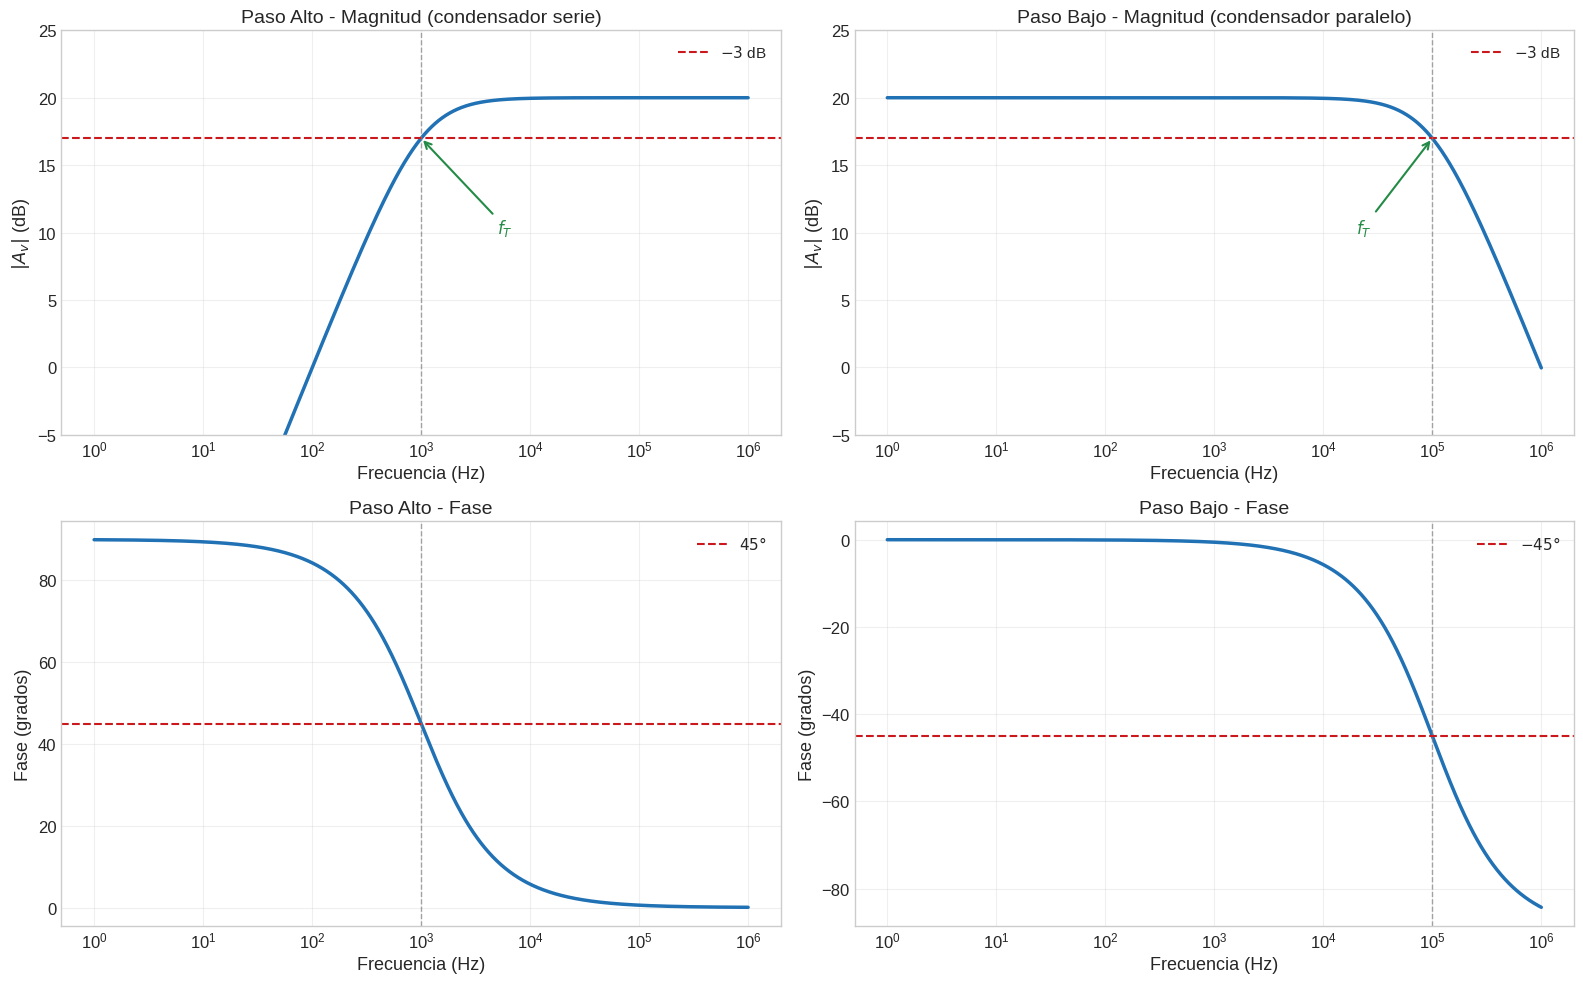

In [2]:
# Diagrama de Bode: filtro paso alto (condensador serie) y paso bajo (condensador paralelo)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Parámetros
f = np.logspace(0, 6, 1000)  # frecuencia en Hz
omega = 2 * np.pi * f
A_prime = 10  # ganancia en banda media

# Frecuencia de corte
f_T = 1000  # Hz
omega_T = 2 * np.pi * f_T

# --- PASO ALTO (condensador serie) ---
Av_hp = A_prime / np.sqrt(1 + (omega_T / omega)**2)
Av_hp_dB = 20 * np.log10(Av_hp)
phase_hp = np.degrees(np.arctan(omega_T / omega))  # fase positiva (adelanto)

# Magnitud
axes[0, 0].semilogx(f, Av_hp_dB, color=COLOR_PRINCIPAL, lw=2.5)
axes[0, 0].axhline(y=20*np.log10(A_prime) - 3, color=COLOR_RECTA, ls='--', lw=1.5, label=r'$-3$ dB')
axes[0, 0].axvline(x=f_T, color='gray', ls='--', lw=1, alpha=0.7)
axes[0, 0].set_xlabel(r'Frecuencia (Hz)')
axes[0, 0].set_ylabel(r'$|A_v|$ (dB)')
axes[0, 0].set_title(r'Paso Alto - Magnitud (condensador serie)')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-5, 25)
axes[0, 0].annotate(r'$f_T$', xy=(f_T, 20*np.log10(A_prime)-3), xytext=(f_T*5, 10),
                     fontsize=12, color=COLOR_PUNTO, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

# Fase
axes[1, 0].semilogx(f, phase_hp, color=COLOR_PRINCIPAL, lw=2.5)
axes[1, 0].axhline(y=45, color=COLOR_RECTA, ls='--', lw=1.5, label=r'$45°$')
axes[1, 0].axvline(x=f_T, color='gray', ls='--', lw=1, alpha=0.7)
axes[1, 0].set_xlabel(r'Frecuencia (Hz)')
axes[1, 0].set_ylabel(r'Fase (grados)')
axes[1, 0].set_title(r'Paso Alto - Fase')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# --- PASO BAJO (condensador paralelo) ---
f_T2 = 100000  # 100 kHz
omega_T2 = 2 * np.pi * f_T2
Av_lp = A_prime / np.sqrt(1 + (omega / omega_T2)**2)
Av_lp_dB = 20 * np.log10(Av_lp)
phase_lp = -np.degrees(np.arctan(omega / omega_T2))

# Magnitud
axes[0, 1].semilogx(f, Av_lp_dB, color=COLOR_PRINCIPAL, lw=2.5)
axes[0, 1].axhline(y=20*np.log10(A_prime) - 3, color=COLOR_RECTA, ls='--', lw=1.5, label=r'$-3$ dB')
axes[0, 1].axvline(x=f_T2, color='gray', ls='--', lw=1, alpha=0.7)
axes[0, 1].set_xlabel(r'Frecuencia (Hz)')
axes[0, 1].set_ylabel(r'$|A_v|$ (dB)')
axes[0, 1].set_title(r'Paso Bajo - Magnitud (condensador paralelo)')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-5, 25)
axes[0, 1].annotate(r'$f_T$', xy=(f_T2, 20*np.log10(A_prime)-3), xytext=(f_T2/5, 10),
                     fontsize=12, color=COLOR_PUNTO, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

# Fase
axes[1, 1].semilogx(f, phase_lp, color=COLOR_PRINCIPAL, lw=2.5)
axes[1, 1].axhline(y=-45, color=COLOR_RECTA, ls='--', lw=1.5, label=r'$-45°$')
axes[1, 1].axvline(x=f_T2, color='gray', ls='--', lw=1, alpha=0.7)
axes[1, 1].set_xlabel(r'Frecuencia (Hz)')
axes[1, 1].set_ylabel(r'Fase (grados)')
axes[1, 1].set_title(r'Paso Bajo - Fase')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# PARTE 2: Amplificador Operacional (Tema 7)

---

## 7. El amplificador diferencial

### 7.1 Concepto

Un **amplificador diferencial** amplifica la diferencia entre dos señales de entrada:

$$\boxed{V_{out} = A_d \cdot (V^+ - V^-)}$$

donde $A_d$ es la **ganancia diferencial**.

### 7.2 Modo diferencial vs modo común

Cualquier par de señales $V_1$, $V_2$ se descompone en:

$$V_d = V_1 - V_2 \quad \text{(modo diferencial)}$$
$$V_c = \frac{V_1 + V_2}{2} \quad \text{(modo común)}$$

La salida real incluye ambas componentes:

$$V_{out} = A_d \cdot V_d + A_c \cdot V_c$$

donde $A_c$ es la ganancia en modo común (idealmente **cero**).

### 7.3 CMRR (Relación de Rechazo al Modo Común)

$$\boxed{CMRR = \frac{A_d}{A_c}} \qquad CMRR_{\text{dB}} = 20 \cdot \log_{10}\left(\frac{A_d}{A_c}\right)$$

- Un CMRR alto significa que el amplificador **rechaza bien** el ruido común a ambas entradas
- OPAM ideal: $CMRR = \infty$

#### Ejercicio resuelto: CMRR

**Datos:** $A_d = 10^5$, $CMRR = 80$ dB. Señales: $V_1 = 5.001$ V, $V_2 = 4.999$ V.

**Paso 1:** Calcular $V_d$ y $V_c$:

$$V_d = V_1 - V_2 = 5.001 - 4.999 = 0.002\;\text{V} = 2\;\text{mV}$$

$$V_c = \frac{V_1 + V_2}{2} = \frac{5.001 + 4.999}{2} = 5\;\text{V}$$

**Paso 2:** Obtener $A_c$ del CMRR:

$$CMRR_{\text{dB}} = 80 \implies CMRR = 10^{80/20} = 10^4$$

$$A_c = \frac{A_d}{CMRR} = \frac{10^5}{10^4} = 10$$

**Paso 3:** Calcular la salida:

$$V_{out} = A_d \cdot V_d + A_c \cdot V_c = 10^5 \times 0.002 + 10 \times 5 = 200 + 50 = 250\;\text{V}$$

**Nota:** La componente de modo común ($50$ V) introduce un **error del 20%**. En un OPAM ideal ($CMRR = \infty$), la salida sería exactamente $200$ V.

In [ ]:
# Diagrama: Amplificador diferencial (CMRR)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Amplificador diferencial', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entradas
d += elm.Line().right().length(2).label(r'$V_1 = 5.001$ V', loc='left')

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# Entrada V2
d += elm.Line().at(opamp.in2).left().length(2).label(r'$V_2 = 4.999$ V', loc='left')

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Anotaciones
ax.text(0.02, 0.02, r'$V_{out} = A_d \cdot V_d + A_c \cdot V_c$'
        '\n' r'$V_d = V_1 - V_2 = 2$ mV'
        '\n' r'$V_c = (V_1 + V_2)/2 = 5$ V',
        transform=ax.transAxes, fontsize=11, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

---

## 8. El OPAM ideal

### 8.1 Propiedades del OPAM ideal

| Propiedad | Valor ideal | Consecuencia |
|:---|:---:|:---|
| Ganancia diferencial $A_d$ | $\infty$ | Cualquier $V_d \neq 0$ satura la salida |
| Resistencia de entrada $R_i$ | $\infty$ | $I^+ = I^- = 0$ (no entra corriente) |
| Resistencia de salida $R_o$ | $0$ | Entrega cualquier corriente sin caída |
| $CMRR$ | $\infty$ | Rechaza totalmente el ruido común |
| Ancho de banda | $\infty$ | Funciona a cualquier frecuencia |

### 8.2 Las dos reglas de oro del OPAM ideal (con realimentación negativa)

$$\boxed{I^+ = I^- = 0 \quad \text{(no entra corriente por las entradas)}}$$

$$\boxed{V^+ = V^- \quad \text{(tierra virtual / cortocircuito virtual)}}$$

**Error frecuente:** Estas reglas SOLO son válidas cuando hay **realimentación negativa** (conexión de la salida a la entrada inversora $V^-$). Sin realimentación, el OPAM funciona como comparador.

### 8.3 Curva característica

- **Ideal:** línea vertical en $V_d = 0$ (ganancia infinita)
- **Real:** pendiente finita con **saturación** a $\pm V_{cc}$

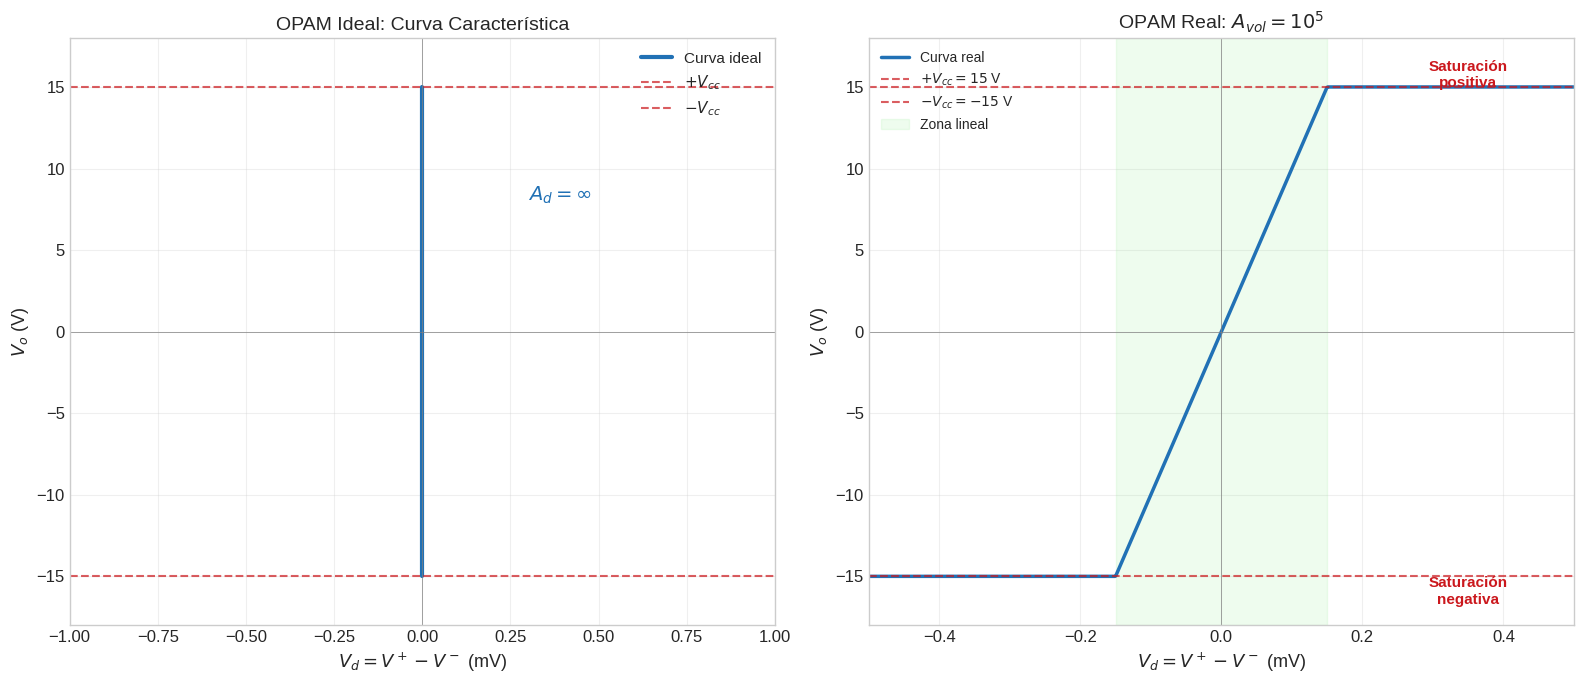

In [3]:
# Curva característica del OPAM: ideal vs real
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- OPAM IDEAL ---
axes[0].plot([0, 0], [-15, 15], color=COLOR_PRINCIPAL, lw=3, label='Curva ideal')
axes[0].axhline(y=15, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$+V_{cc}$')
axes[0].axhline(y=-15, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$-V_{cc}$')
axes[0].axhline(y=0, color='gray', lw=0.5)
axes[0].axvline(x=0, color='gray', lw=0.5)
axes[0].set_xlabel(r'$V_d = V^+ - V^-$ (mV)')
axes[0].set_ylabel(r'$V_o$ (V)')
axes[0].set_title('OPAM Ideal: Curva Característica')
axes[0].set_xlim(-1, 1)
axes[0].set_ylim(-18, 18)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(r'$A_d = \infty$', xy=(0.3, 8), fontsize=14, color=COLOR_PRINCIPAL, fontweight='bold')

# --- OPAM REAL ---
Vcc = 15
Avol = 1e5  # ganancia lazo abierto
Vd_real = np.linspace(-0.5, 0.5, 1000)  # en mV
Vo_real = np.clip(Avol * Vd_real * 1e-3, -Vcc, Vcc)

axes[1].plot(Vd_real, Vo_real, color=COLOR_PRINCIPAL, lw=2.5, label='Curva real')
axes[1].axhline(y=Vcc, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$+V_{cc} = 15$ V')
axes[1].axhline(y=-Vcc, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$-V_{cc} = -15$ V')
axes[1].axhline(y=0, color='gray', lw=0.5)
axes[1].axvline(x=0, color='gray', lw=0.5)

# Zona lineal
axes[1].axvspan(-Vcc/Avol*1e3, Vcc/Avol*1e3, alpha=0.15, color='lightgreen', label='Zona lineal')

axes[1].set_xlabel(r'$V_d = V^+ - V^-$ (mV)')
axes[1].set_ylabel(r'$V_o$ (V)')
axes[1].set_title(r'OPAM Real: $A_{vol} = 10^5$')
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_ylim(-18, 18)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Saturación\npositiva', xy=(0.35, 15), fontsize=11, color=COLOR_RECTA,
                 fontweight='bold', ha='center')
axes[1].annotate('Saturación\nnegativa', xy=(0.35, -15), fontsize=11, color=COLOR_RECTA,
                 fontweight='bold', ha='center', va='top')

plt.tight_layout()
plt.show()

---

## 9. Configuraciones con realimentación negativa

Esta es la sección **más importante** del OPAM. Todas las configuraciones se analizan con las dos reglas de oro:
1. $I^+ = I^- = 0$
2. $V^+ = V^-$ (tierra virtual)

### 9.1 Amplificador Inversor

$$\boxed{V_{out} = -\frac{R_2}{R_1} \cdot V_{in}}$$

| Propiedad | Valor |
|:---|:---|
| Ganancia | $A_v = -R_2/R_1$ |
| Impedancia de entrada | $Z_{in} = R_1$ (la entrada inversora está a tierra virtual) |
| Impedancia de salida | $Z_{out} \approx 0$ (propiedad del OPAM) |
| Fase | **Invierte la señal** (desfase de $180°$) |

**Deducción:** Como $V^+ = 0$ (conectado a tierra), por tierra virtual $V^- = 0$. Nudo en $V^-$:
$$\frac{V_{in} - 0}{R_1} + \frac{V_{out} - 0}{R_2} = 0 \implies V_{out} = -\frac{R_2}{R_1} V_{in}$$

#### Ejercicio resuelto: Amplificador inversor

**Datos:** $R_1 = 10\;\text{k}\Omega$, $R_2 = 47\;\text{k}\Omega$, $V_{in} = 0.5$ V

**Paso 1:** Calcular la ganancia:

$$A_v = -\frac{R_2}{R_1} = -\frac{47\text{k}}{10\text{k}} = -4.7$$

**Paso 2:** Calcular la salida:

$$V_{out} = A_v \cdot V_{in} = -4.7 \times 0.5 = -2.35\;\text{V}$$

**Resultado:** $V_{out} = -2.35$ V (señal invertida y amplificada 4.7 veces)

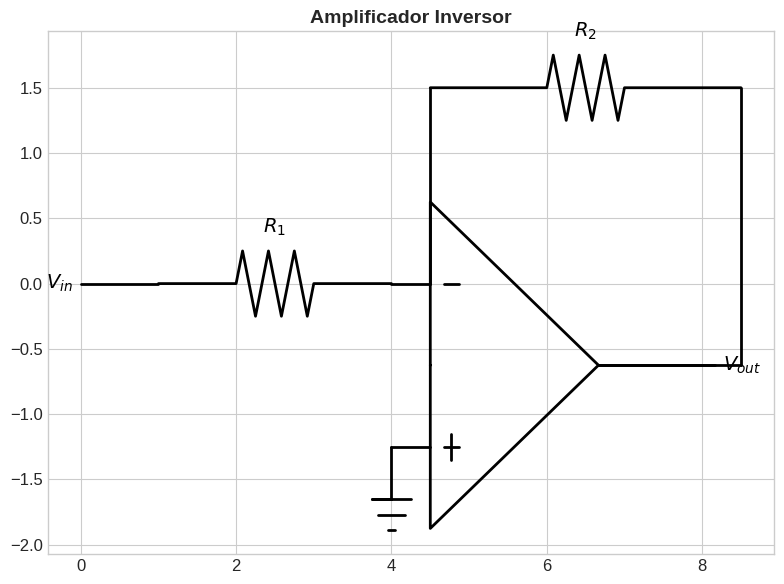

In [4]:
# Diagrama: Amplificador inversor
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Amplificador Inversor', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R_1$', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# R2 (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

### 9.2 Amplificador No Inversor

$$\boxed{V_{out} = \left(1 + \frac{R_2}{R_1}\right) \cdot V_{in}}$$

| Propiedad | Valor |
|:---|:---|
| Ganancia | $A_v = 1 + R_2/R_1$ (siempre $\geq 1$) |
| Impedancia de entrada | $Z_{in} = \infty$ (la señal entra por la entrada no inversora) |
| Impedancia de salida | $Z_{out} \approx 0$ |
| Fase | **No invierte la señal** |

**Deducción:** $V_{in}$ se aplica a $V^+$. Por tierra virtual: $V^- = V^+ = V_{in}$. Divisor de tensión en la realimentación:
$$V^- = V_{out} \cdot \frac{R_1}{R_1 + R_2} = V_{in} \implies V_{out} = \left(1 + \frac{R_2}{R_1}\right) V_{in}$$

#### Ejercicio resuelto: Amplificador no inversor

**Datos:** $R_1 = 4.7\;\text{k}\Omega$, $R_2 = 22\;\text{k}\Omega$, $V_{in} = 0.3$ V

**Paso 1:** Calcular la ganancia:

$$A_v = 1 + \frac{R_2}{R_1} = 1 + \frac{22\text{k}}{4.7\text{k}} = 1 + 4.681 = 5.681$$

**Paso 2:** Calcular la salida:

$$V_{out} = 5.681 \times 0.3 = 1.704\;\text{V}$$

**Resultado:** $V_{out} = 1.70$ V (señal amplificada sin inversión)

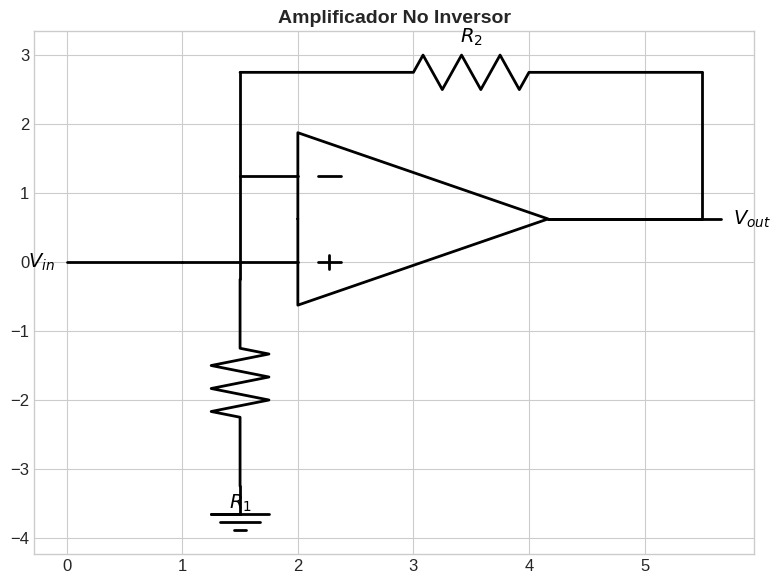

In [5]:
# Diagrama: Amplificador no inversor
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Amplificador No Inversor', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada no inversora
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación: R1 a tierra, R2 en realimentación
d += elm.Line().at(opamp.in1).left().length(0.5)
inv_node = d.here
d += elm.Line().down().length(1.5)
d += elm.Resistor().down().label(r'$R_1$', loc='left')
d += elm.Ground()

# R2 desde inv_node hasta salida
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 9.3 Seguidor de Tensión (Buffer)

$$\boxed{V_{out} = V_{in}}$$

| Propiedad | Valor |
|:---|:---|
| Ganancia | $A_v = 1$ |
| Impedancia de entrada | $Z_{in} = \infty$ |
| Impedancia de salida | $Z_{out} \approx 0$ |

**¿Para qué sirve si no amplifica?** El seguidor de tensión **aísla** etapas: toma una señal de una fuente con alta impedancia y la entrega a una carga con baja impedancia sin atenuación. Es el caso especial del no inversor con $R_2 = 0$ y $R_1 = \infty$.

**Aplicación típica:** Adaptar impedancias entre un sensor (alta $R_s$) y un ADC (baja $R_{in}$).

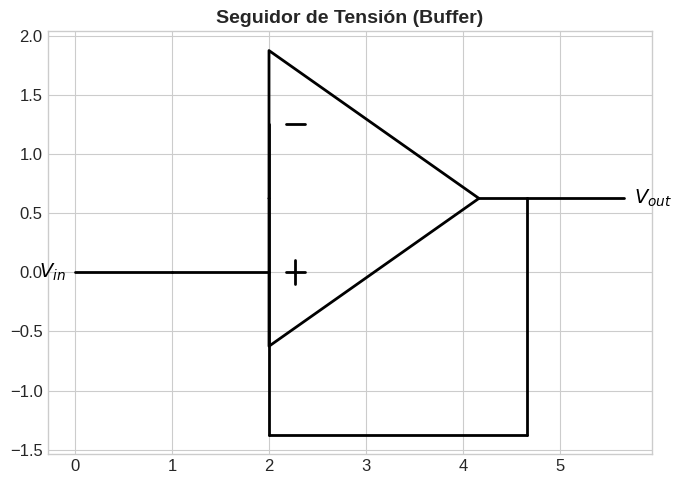

In [6]:
# Diagrama: Seguidor de tensión (buffer)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Seguidor de Tensión (Buffer)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación directa
d += elm.Line().at(opamp.out).right().length(0.5)
out_node = d.here
d += elm.Line().down().length(2)
d += elm.Line().left().tox(opamp.in1)
d += elm.Line().up().toy(opamp.in1)

# Salida
d += elm.Line().at(out_node).right().length(1).label(r'$V_{out}$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 9.4 Amplificador Sumador Inversor

$$\boxed{V_{out} = -R_f \left(\frac{V_1}{R_1} + \frac{V_2}{R_2} + \frac{V_3}{R_3} + \cdots\right)}$$

Si todas las resistencias son iguales ($R_1 = R_2 = R_3 = R_f = R$):

$$V_{out} = -(V_1 + V_2 + V_3 + \cdots)$$

| Propiedad | Valor |
|:---|:---|
| Ganancia para cada entrada | $A_{v_k} = -R_f/R_k$ |
| Impedancia de entrada | $Z_{in_k} = R_k$ (independientes) |
| Superposición | Cada entrada contribuye de forma independiente |

**Aplicación:** Mezclador de audio, convertidor digital-analógico (DAC).

#### Ejercicio resuelto: Amplificador sumador

**Datos:** $R_1 = 10\;\text{k}\Omega$, $R_2 = 20\;\text{k}\Omega$, $R_f = 40\;\text{k}\Omega$, $V_1 = 1$ V, $V_2 = -0.5$ V

**Paso 1:** Aplicar la fórmula del sumador:

$$V_{out} = -R_f \left(\frac{V_1}{R_1} + \frac{V_2}{R_2}\right) = -40\text{k} \left(\frac{1}{10\text{k}} + \frac{-0.5}{20\text{k}}\right)$$

**Paso 2:** Calcular cada término:

$$V_{out} = -40\text{k} \left(0.1 \times 10^{-3} + (-0.025 \times 10^{-3})\right) = -40\text{k} \times 0.075 \times 10^{-3}$$

Simplificando:

$$V_{out} = -40 \times (0.1 - 0.025) = -40 \times 0.075 = -3\;\text{V}$$

**Resultado:** $V_{out} = -3$ V

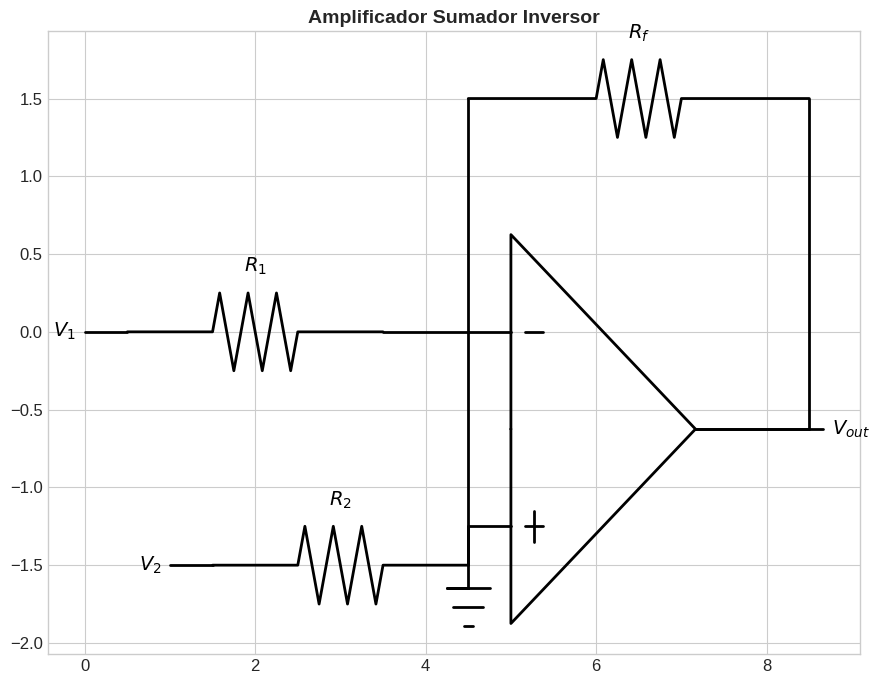

In [7]:
# Diagrama: Amplificador sumador inversor
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title('Amplificador Sumador Inversor', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada V1
d += elm.Line().right().length(0.5).label(r'$V_1$', loc='left')
d += elm.Resistor().right().label(r'$R_1$', loc='top')
d += elm.Line().right().length(1)
node_inv = d.here

# Entrada V2 (debajo)
d += elm.Line().at(node_inv).down().length(1.5)
node_v2 = d.here
d += elm.Resistor().left().label(r'$R_2$', loc='top').length(3)
d += elm.Line().left().length(0.5).label(r'$V_2$', loc='left')

# OPAM
d += elm.Line().at(node_inv).right().length(0.5)
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# Rf (realimentación)
d += elm.Line().at(node_inv).up().length(1.5)
d += elm.Resistor().right().label(r'$R_f$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

### 9.5 Diferenciador

$$\boxed{V_{out} = -R \cdot C \cdot \frac{dV_{in}}{dt}}$$

| Propiedad | Valor |
|:---|:---|
| Función | Calcula la derivada de la señal de entrada |
| Entrada rampa | Salida: constante |
| Entrada senoidal $V_{in} = V_A \sin(\omega t)$ | $V_{out} = -RC \omega V_A \cos(\omega t)$ |
| Impedancia de entrada | $Z_{in} = 1/(j\omega C)$ (depende de la frecuencia) |

**Precaución:** El diferenciador amplifica el ruido de alta frecuencia (la ganancia crece con $\omega$).

#### Ejercicio resuelto: Diferenciador

**Datos:** $R = 10\;\text{k}\Omega$, $C = 1\;\mu\text{F}$, $V_{in}(t) = 2\sin(2\pi \cdot 100 \cdot t)$ V

**Paso 1:** Calcular $RC$:

$$RC = 10 \times 10^3 \times 1 \times 10^{-6} = 0.01\;\text{s}$$

**Paso 2:** La derivada de la entrada:

$$\frac{dV_{in}}{dt} = 2 \cdot 2\pi \cdot 100 \cdot \cos(2\pi \cdot 100 \cdot t) = 400\pi \cos(2\pi \cdot 100 \cdot t)$$

**Paso 3:** La salida:

$$V_{out} = -RC \cdot \frac{dV_{in}}{dt} = -0.01 \times 400\pi \cos(2\pi \cdot 100 \cdot t)$$

$$V_{out} = -4\pi \cos(2\pi \cdot 100 \cdot t) \approx -12.57 \cos(2\pi \cdot 100 \cdot t)\;\text{V}$$

**Resultado:** La amplitud de salida es $12.57$ V con un desfase de $90°$.

In [ ]:
# Diagrama: Diferenciador (C en entrada, R en realimentación)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Diferenciador', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada con condensador
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Capacitor().right().label(r'$C = 1\;\mu$F', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# R (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R = 10\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

# Fórmula
ax.text(0.02, 0.02, r'$V_{out} = -RC \cdot \frac{dV_{in}}{dt}$', transform=ax.transAxes,
        fontsize=13, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

### 9.6 Integrador

$$\boxed{V_{out} = -\frac{1}{R \cdot C} \int V_{in} \, dt}$$

| Propiedad | Valor |
|:---|:---|
| Función | Calcula la integral de la señal de entrada |
| Entrada escalón $V_0$ | Salida: rampa $V_{out} = -\frac{V_0}{RC} \cdot t$ |
| Entrada senoidal | $V_{out} = \frac{V_A}{RC\omega} \cos(\omega t)$ |
| Impedancia de realimentación | $Z_f = 1/(j\omega C)$ (crece a baja frecuencia) |

**Precaución:** En DC ($\omega = 0$), la ganancia tiende a infinito $\to$ el OPAM se satura. En la práctica se añade una resistencia en paralelo con $C$.

#### Ejercicio resuelto: Integrador

**Datos:** $R = 100\;\text{k}\Omega$, $C = 10\;\mu\text{F}$, $V_{in} = 2$ V (escalón constante)

**Paso 1:** Calcular $RC$:

$$RC = 100 \times 10^3 \times 10 \times 10^{-6} = 1\;\text{s}$$

**Paso 2:** Aplicar la fórmula del integrador para entrada constante:

$$V_{out}(t) = -\frac{1}{RC} \int_0^t V_{in} \, dt' = -\frac{1}{1} \cdot 2 \cdot t = -2t$$

**Paso 3:** Evaluar en instantes concretos:

| $t$ (s) | $V_{out}$ (V) |
|:---:|:---:|
| 0 | 0 |
| 1 | -2 |
| 2 | -4 |
| 5 | -10 |

**Resultado:** La salida es una **rampa descendente** con pendiente $-2$ V/s. En la realidad, el OPAM saturará en $-V_{cc}$.

In [ ]:
# Diagrama: Integrador (R en entrada, C en realimentación)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Integrador', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada con resistencia
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R = 100\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# C (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Capacitor().right().label(r'$C = 10\;\mu$F', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

# Fórmula
ax.text(0.02, 0.02, r'$V_{out} = -\frac{1}{RC} \int V_{in}\, dt$', transform=ax.transAxes,
        fontsize=13, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

---

## 10. Realimentación positiva: Trigger de Schmitt

### 10.1 Concepto

El **trigger de Schmitt** es un comparador con **histéresis**. La realimentación positiva (de la salida a la entrada no inversora $V^+$) crea dos umbrales de conmutación diferentes:

$$\boxed{V_{T+} = +V_{cc} \cdot \frac{R_1}{R_2}} \qquad \boxed{V_{T-} = -V_{cc} \cdot \frac{R_1}{R_2}}$$

(para el caso de entrada por $V^-$ y divisor $R_1$-$R_2$ en la realimentación positiva)

### 10.2 Histéresis

$$\boxed{\Delta V = V_{T+} - V_{T-} = (V_{cc} + V_{ee}) \cdot \frac{R_1}{R_2}}$$

Con alimentación simétrica ($V_{ee} = -V_{cc}$):

$$\Delta V = 2 V_{cc} \cdot \frac{R_1}{R_2}$$

### 10.3 Comportamiento

- Si $V_{in} < V_{T-}$: salida salta a $+V_{cc}$
- Si $V_{in} > V_{T+}$: salida salta a $-V_{cc}$
- Entre $V_{T-}$ y $V_{T+}$: la salida **mantiene su estado anterior** (memoria)

**Aplicación:** Eliminar rebotes en señales ruidosas, generar ondas cuadradas desde senoidales.

#### Ejercicio resuelto: Trigger de Schmitt

**Datos:** $V_{cc} = 12$ V (alimentación simétrica $\pm 12$ V), $R_1 = 10\;\text{k}\Omega$, $R_2 = 100\;\text{k}\Omega$

**Paso 1:** Calcular los umbrales:

$$V_{T+} = V_{cc} \cdot \frac{R_1}{R_2} = 12 \cdot \frac{10\text{k}}{100\text{k}} = 12 \times 0.1 = 1.2\;\text{V}$$

$$V_{T-} = -V_{cc} \cdot \frac{R_1}{R_2} = -12 \times 0.1 = -1.2\;\text{V}$$

**Paso 2:** Calcular la histéresis:

$$\Delta V = V_{T+} - V_{T-} = 1.2 - (-1.2) = 2.4\;\text{V}$$

**Resultado:** El trigger conmuta hacia $+12$ V cuando la entrada baja de $-1.2$ V, y hacia $-12$ V cuando la entrada sube de $+1.2$ V. La ventana de histéresis es $2.4$ V.

In [ ]:
# Diagrama: Trigger de Schmitt (realimentación positiva)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Trigger de Schmitt ($R_1 = 10\;\mathrm{k}\Omega$, $R_2 = 100\;\mathrm{k}\Omega$)', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada a la inversora
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R_1 = 10\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(0.5)

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# Salida
d += elm.Line().at(opamp.out).right().length(1.5)
out_node = d.here
d += elm.Line().right().length(0.5).label(r'$V_{out}$', loc='right')

# Realimentación POSITIVA: de salida a in2 (no inversora)
d += elm.Line().at(out_node).up().length(2)
d += elm.Resistor().left().label(r'$R_2 = 100\;\mathrm{k}\Omega$', loc='top').length(5)
d += elm.Line().down().toy(opamp.in2)
d += elm.Line().right().tox(opamp.in2)

d.draw()
plt.tight_layout()
plt.show()

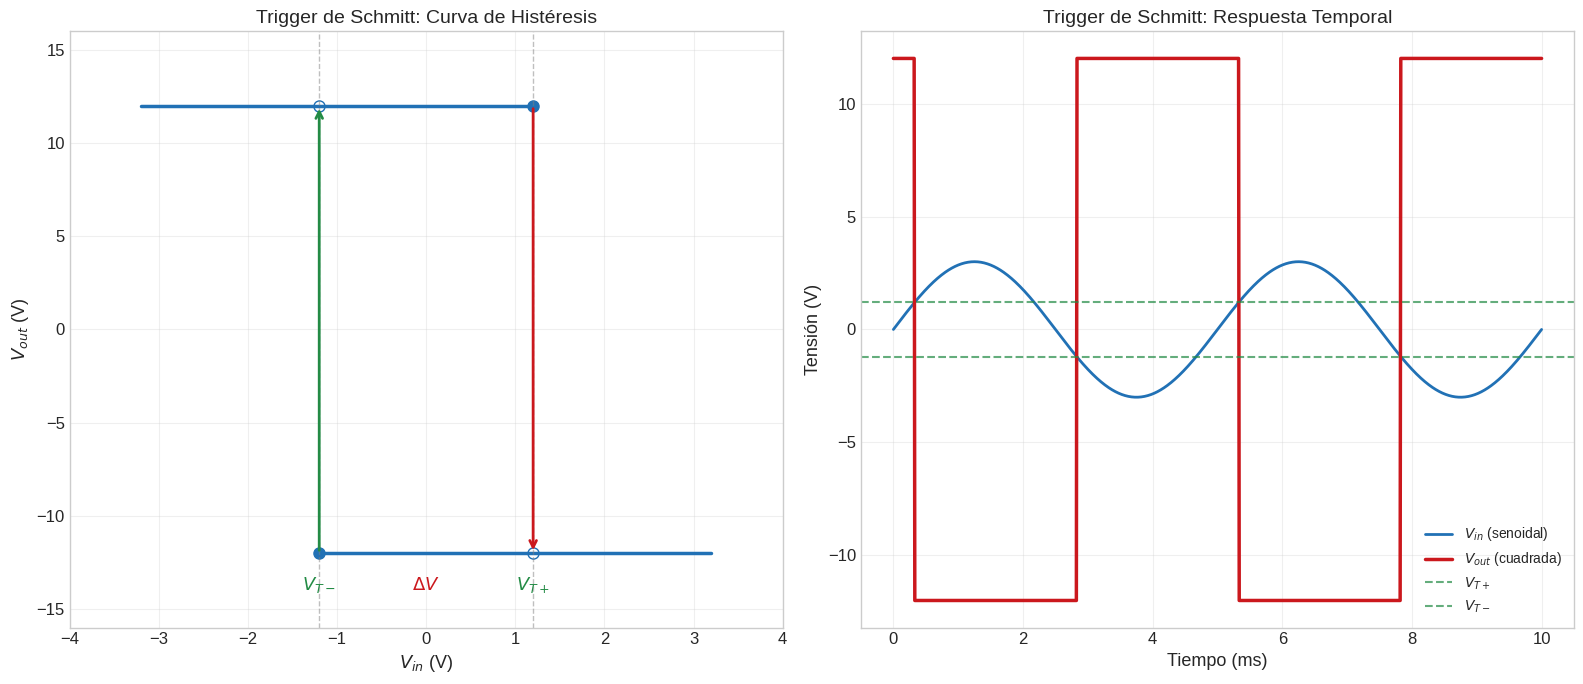

In [8]:
# Curva de histéresis del trigger de Schmitt
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

Vcc = 12
R1, R2 = 10e3, 100e3
VTp = Vcc * R1 / R2    # +1.2 V
VTn = -Vcc * R1 / R2   # -1.2 V

# --- Curva de histéresis ---
ax = axes[0]
# Rama ascendente (salida en +Vcc, conmuta en VTp)
ax.plot([VTn - 2, VTp], [Vcc, Vcc], color=COLOR_PRINCIPAL, lw=2.5)
ax.plot([VTp], [Vcc], 'o', color=COLOR_PRINCIPAL, ms=8)
ax.plot([VTp], [-Vcc], 'o', color=COLOR_PRINCIPAL, ms=8, fillstyle='none')

# Transición descendente
ax.annotate('', xy=(VTp, -Vcc), xytext=(VTp, Vcc),
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2))

# Rama descendente (salida en -Vcc, conmuta en VTn)
ax.plot([VTn, VTp + 2], [-Vcc, -Vcc], color=COLOR_PRINCIPAL, lw=2.5)
ax.plot([VTn], [-Vcc], 'o', color=COLOR_PRINCIPAL, ms=8)
ax.plot([VTn], [Vcc], 'o', color=COLOR_PRINCIPAL, ms=8, fillstyle='none')

# Transición ascendente
ax.annotate('', xy=(VTn, Vcc), xytext=(VTn, -Vcc),
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2))

ax.axvline(x=VTp, color='gray', ls='--', lw=1, alpha=0.5)
ax.axvline(x=VTn, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel(r'$V_{in}$ (V)')
ax.set_ylabel(r'$V_{out}$ (V)')
ax.set_title('Trigger de Schmitt: Curva de Histéresis')
ax.set_xlim(-4, 4)
ax.set_ylim(-16, 16)
ax.grid(True, alpha=0.3)
ax.annotate(r'$V_{T+}$', xy=(VTp, -14), fontsize=13, color=COLOR_PUNTO, ha='center', fontweight='bold')
ax.annotate(r'$V_{T-}$', xy=(VTn, -14), fontsize=13, color=COLOR_PUNTO, ha='center', fontweight='bold')
ax.annotate(r'$\Delta V$', xy=(0, -Vcc - 2), fontsize=13, color=COLOR_RECTA, ha='center', fontweight='bold')

# --- Señal temporal ---
ax = axes[1]
t = np.linspace(0, 0.01, 1000)
Vin = 3 * np.sin(2 * np.pi * 200 * t)

# Simular el trigger de Schmitt
Vout = np.zeros_like(t)
state = Vcc  # estado inicial
for i in range(len(t)):
    if Vin[i] > VTp:
        state = -Vcc
    elif Vin[i] < VTn:
        state = Vcc
    Vout[i] = state

ax.plot(t * 1e3, Vin, color=COLOR_PRINCIPAL, lw=2, label=r'$V_{in}$ (senoidal)')
ax.plot(t * 1e3, Vout, color=COLOR_RECTA, lw=2.5, label=r'$V_{out}$ (cuadrada)')
ax.axhline(y=VTp, color=COLOR_PUNTO, ls='--', lw=1.5, alpha=0.7, label=r'$V_{T+}$')
ax.axhline(y=VTn, color=COLOR_PUNTO, ls='--', lw=1.5, alpha=0.7, label=r'$V_{T-}$')
ax.set_xlabel(r'Tiempo (ms)')
ax.set_ylabel(r'Tensión (V)')
ax.set_title('Trigger de Schmitt: Respuesta Temporal')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 11. OPAM real: Limitaciones prácticas

### 11.1 Imperfecciones DC

| Parámetro | Significado | Valor típico |
|:---|:---|:---|
| **Tensión de offset** $V_{os}$ | Tensión necesaria entre entradas para que $V_{out} = 0$ | $1-10$ mV |
| **Corriente de polarización** $I_B$ | Media de las corrientes de entrada: $I_B = (I_{B+} + I_{B-})/2$ | $10-100$ nA |
| **Corriente de offset** $I_{os}$ | Diferencia: $I_{os} = |I_{B+} - I_{B-}|$ | $1-10$ nA |

### 11.2 Producto ganancia-ancho de banda (GBW)

$$\boxed{A_v \cdot B = A_{vol} \cdot f_c = GBW = \text{constante}}$$

donde:
- $A_{vol}$: ganancia en lazo abierto (ej. $10^5$)
- $f_c$: frecuencia de corte en lazo abierto (ej. $10$ Hz)
- $GBW$: producto ganancia-ancho de banda (ej. $1$ MHz para un 741)

**Consecuencia:** Si se configura el OPAM con ganancia $A_v = 100$, el ancho de banda es:

$$B = \frac{GBW}{A_v} = \frac{10^6}{100} = 10\;\text{kHz}$$

A mayor ganancia, menor ancho de banda. La curva de ganancia en lazo abierto decae a $-20$ dB/década.

### 11.3 Slew Rate (Velocidad de respuesta)

$$\boxed{SR = \left(\frac{dV_{out}}{dt}\right)_{\max}}$$

Para una senoidal $V_{out} = V_A \sin(\omega t)$:

$$\left(\frac{dV_{out}}{dt}\right)_{\max} = \omega \cdot V_A = 2\pi f \cdot V_A$$

Para evitar distorsión por slew rate:

$$\boxed{2\pi f \cdot V_A \leq SR}$$

$$f_{\max} = \frac{SR}{2\pi V_A}$$

**Ejemplo:** 741 tiene $SR = 0.5$ V/$\mu$s. Para $V_A = 10$ V:

$$f_{\max} = \frac{0.5 \times 10^6}{2\pi \times 10} = 7.96\;\text{kHz}$$

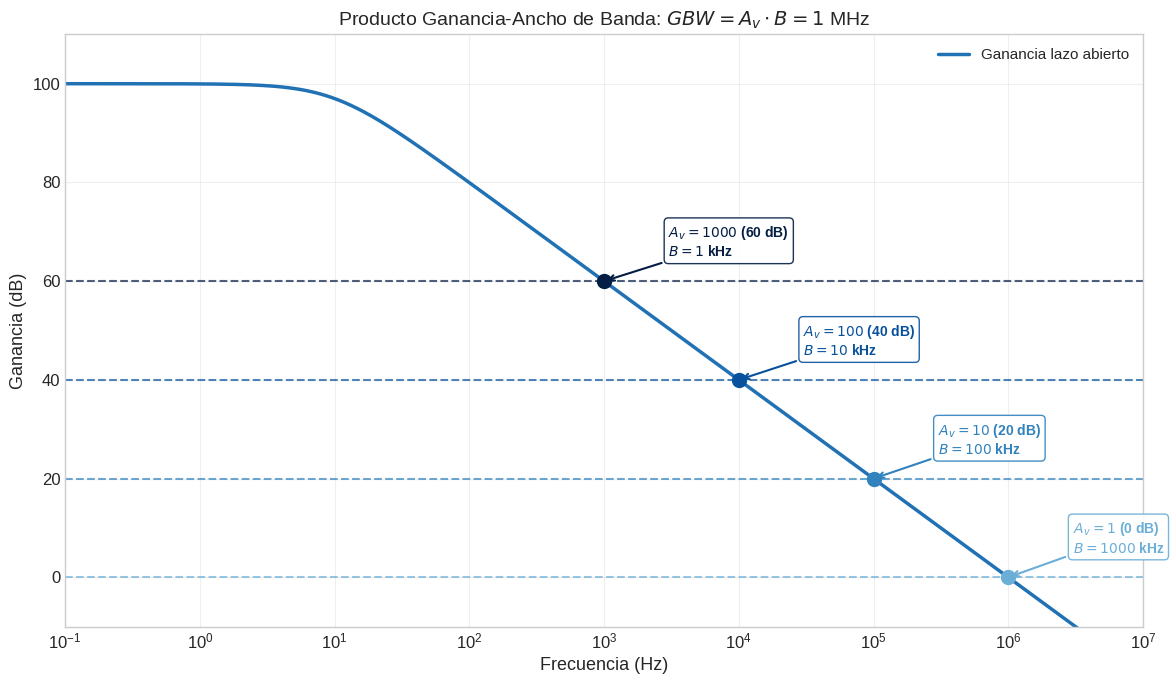

In [9]:
# Producto ganancia-ancho de banda (GBW)
fig, ax = plt.subplots(figsize=(12, 7))

# Parámetros del OPAM (ej. 741)
GBW = 1e6       # 1 MHz
Avol = 1e5      # ganancia lazo abierto
fc = GBW / Avol  # frecuencia de corte lazo abierto = 10 Hz

f = np.logspace(-1, 7, 1000)

# Ganancia lazo abierto
Av_open = Avol / np.sqrt(1 + (f / fc)**2)
Av_open_dB = 20 * np.log10(Av_open)

ax.semilogx(f, Av_open_dB, color=COLOR_PRINCIPAL, lw=2.5, label='Ganancia lazo abierto')

# Ganancias con realimentación
ganancias = [1, 10, 100, 1000]
colores_g = ['#6baed6', '#3182bd', '#08519c', '#031d44']
for Av_val, color in zip(ganancias, colores_g):
    BW = GBW / Av_val
    Av_dB = 20 * np.log10(Av_val)
    ax.axhline(y=Av_dB, color=color, ls='--', lw=1.5, alpha=0.7)
    ax.plot(BW, Av_dB, 'o', color=color, ms=10, zorder=5)
    if BW >= 1e3:
        label_text = f'$A_v = {Av_val}$ ({Av_dB:.0f} dB)\n$B = {BW/1e3:.0f}$ kHz'
    else:
        label_text = f'$A_v = {Av_val}$ ({Av_dB:.0f} dB)\n$B = {BW:.0f}$ Hz'
    ax.annotate(label_text,
                xy=(BW, Av_dB), xytext=(BW * 3, Av_dB + 5),
                fontsize=10, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=color, alpha=0.9))

ax.set_xlabel(r'Frecuencia (Hz)')
ax.set_ylabel(r'Ganancia (dB)')
ax.set_title(r'Producto Ganancia-Ancho de Banda: $GBW = A_v \cdot B = 1$ MHz')
ax.set_xlim(1e-1, 1e7)
ax.set_ylim(-10, 110)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

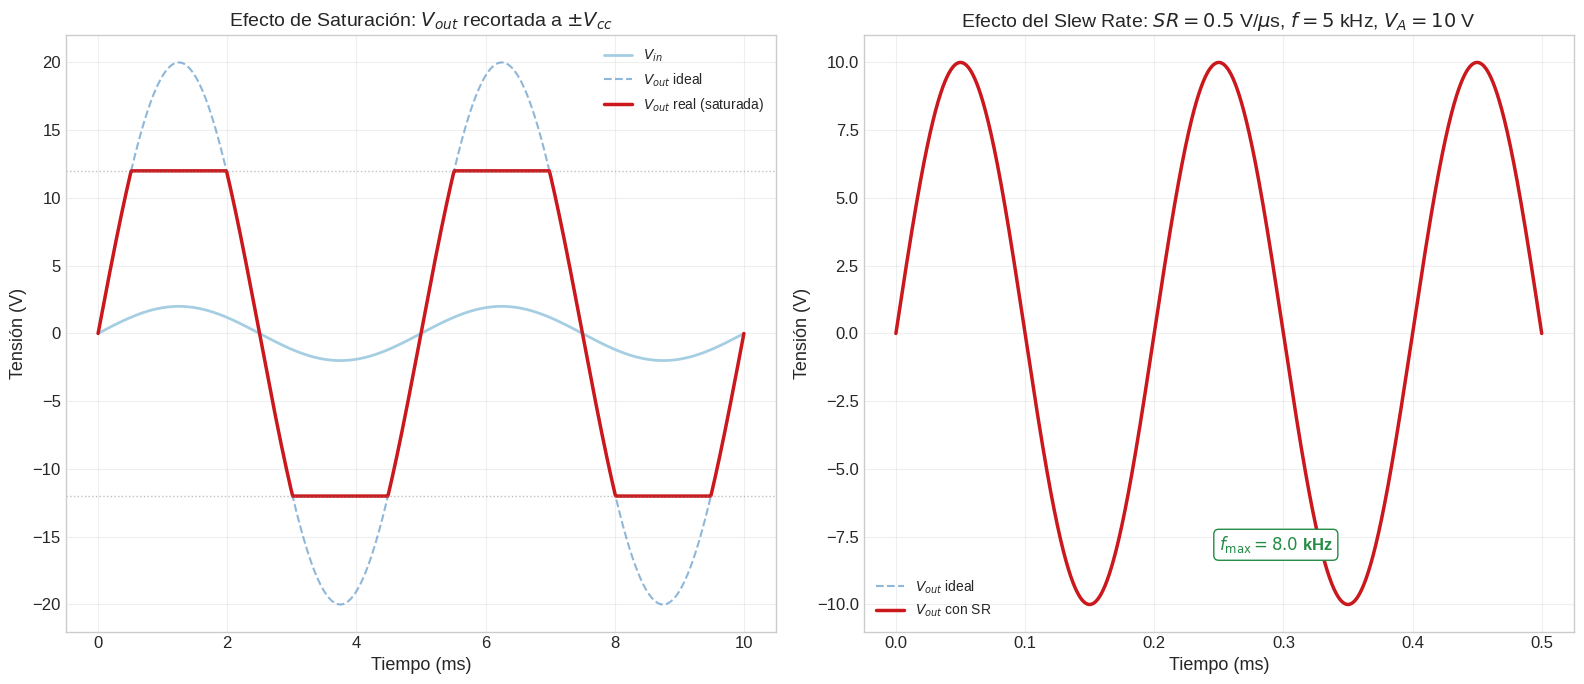

In [10]:
# Efectos del OPAM real: saturación y slew rate
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- SATURACIÓN ---
ax = axes[0]
t = np.linspace(0, 0.01, 1000)
Vin = 2 * np.sin(2 * np.pi * 200 * t)
Av = 10
Vcc = 12
Vout_ideal = Av * Vin
Vout_sat = np.clip(Vout_ideal, -Vcc, Vcc)

ax.plot(t * 1e3, Vin, color=COLOR_N, lw=2, label=r'$V_{in}$')
ax.plot(t * 1e3, Vout_ideal, color=COLOR_PRINCIPAL, lw=1.5, ls='--', alpha=0.5, label=r'$V_{out}$ ideal')
ax.plot(t * 1e3, Vout_sat, color=COLOR_RECTA, lw=2.5, label=r'$V_{out}$ real (saturada)')
ax.axhline(y=Vcc, color='gray', ls=':', lw=1, alpha=0.5)
ax.axhline(y=-Vcc, color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel(r'Tiempo (ms)')
ax.set_ylabel(r'Tensión (V)')
ax.set_title(r'Efecto de Saturación: $V_{out}$ recortada a $\pm V_{cc}$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- SLEW RATE ---
ax = axes[1]
SR = 0.5e6  # 0.5 V/us = 0.5e6 V/s
f_signal = 5000  # 5 kHz
VA = 10  # amplitud
t = np.linspace(0, 0.5e-3, 2000)

# Señal ideal
Vout_ideal = VA * np.sin(2 * np.pi * f_signal * t)

# Señal limitada por slew rate
Vout_sr = np.zeros_like(t)
Vout_sr[0] = Vout_ideal[0]
dt = t[1] - t[0]
for i in range(1, len(t)):
    dV_desired = Vout_ideal[i] - Vout_sr[i-1]
    max_dV = SR * dt
    if abs(dV_desired) > max_dV:
        Vout_sr[i] = Vout_sr[i-1] + np.sign(dV_desired) * max_dV
    else:
        Vout_sr[i] = Vout_ideal[i]

ax.plot(t * 1e3, Vout_ideal, color=COLOR_PRINCIPAL, lw=1.5, ls='--', alpha=0.5, label=r'$V_{out}$ ideal')
ax.plot(t * 1e3, Vout_sr, color=COLOR_RECTA, lw=2.5, label=r'$V_{out}$ con SR')
ax.set_xlabel(r'Tiempo (ms)')
ax.set_ylabel(r'Tensión (V)')
ax.set_title(r'Efecto del Slew Rate: $SR = 0.5$ V/$\mu$s, $f = 5$ kHz, $V_A = 10$ V')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Frecuencia máxima
f_max = SR / (2 * np.pi * VA)
ax.annotate(f'$f_{{\\max}} = {f_max/1e3:.1f}$ kHz', xy=(0.25, -8),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

plt.tight_layout()
plt.show()

---

## 12. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica **todos los tipos de problemas** de OPAM que pueden aparecer en exámenes.

| # | Tipo | Configuración | Ecuación clave | Dificultad |
|:---:|:---|:---|:---|:---:|
| 1 | Amplificador inversor | $R_1$, $R_2$ | $V_{out} = -(R_2/R_1) V_{in}$ | Baja |
| 2 | Amplificador no inversor | $R_1$, $R_2$ | $V_{out} = (1+R_2/R_1) V_{in}$ | Baja |
| 3 | Seguidor de tensión | Realimentación directa | $V_{out} = V_{in}$ | Baja |
| 4 | Sumador inversor | $R_1, R_2, ..., R_f$ | $V_{out} = -R_f(\sum V_k/R_k)$ | Media |
| 5 | Diferenciador | $C$, $R$ | $V_{out} = -RC \cdot dV_{in}/dt$ | Media |
| 6 | Integrador | $R$, $C$ | $V_{out} = -\frac{1}{RC}\int V_{in} dt$ | Media |
| 7 | Amplificadores en cascada | Etapas A, B, C | $A_{total} = A_1 \cdot A_2 \cdot ...$ | Media |
| 8 | Identificar configuración | Circuito dado | Analizar conexiones | Media |
| 9 | Diseño: elegir $R_1$, $R_2$ | Ganancia objetivo | Despejar de fórmulas | Alta |
| 10 | Trigger de Schmitt | $R_1$, $R_2$ realim. positiva | $V_T = \pm V_{cc} R_1/R_2$ | Media |
| 11 | OPAM real: ancho de banda | GBW dado | $B = GBW/A_v$ | Alta |
| 12 | OPAM real: slew rate | SR dado | $2\pi f V_A \leq SR$ | Alta |

### 12.1 Tipo 1: Amplificador inversor - Calcular ganancia y $V_{out}$

$$\boxed{V_{out} = -\frac{R_2}{R_1} \cdot V_{in}}$$

**Clave:** La ganancia es negativa (invierte). La impedancia de entrada es $R_1$.

**Cómo afectan las resistencias:**
- Si **$R_2$ aumenta** $\to$ $|A_v|$ aumenta $\to$ mayor amplificación
- Si **$R_1$ aumenta** $\to$ $|A_v|$ disminuye $\to$ menor amplificación, mayor $Z_{in}$

#### Ejercicio resuelto: Inversor - cálculo rápido

**Datos:** $R_1 = 2.2\;\text{k}\Omega$, $R_2 = 33\;\text{k}\Omega$, $V_{in} = 0.2$ V, $V_{cc} = \pm 15$ V

$$A_v = -\frac{33\text{k}}{2.2\text{k}} = -15$$

$$V_{out} = -15 \times 0.2 = -3\;\text{V}$$

Verificar: $|V_{out}| = 3 < 15 = V_{cc}$ $\to$ **No satura.**

In [ ]:
# Diagrama: Inversor cálculo rápido
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Inversor: $R_1 = 2.2\;\mathrm{k}\Omega$, $R_2 = 33\;\mathrm{k}\Omega$, $V_{in} = 0.2$ V', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada
d += elm.Line().right().length(1).label(r'$V_{in} = 0.2$ V', loc='left')
d += elm.Resistor().right().label(r'$R_1 = 2.2\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# R2 (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2 = 33\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out} = -3$ V', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

### 12.2 Tipo 2: Amplificador no inversor - Calcular ganancia y $V_{out}$

$$\boxed{V_{out} = \left(1 + \frac{R_2}{R_1}\right) \cdot V_{in}}$$

**Clave:** La ganancia es siempre $\geq 1$ y positiva. Impedancia de entrada infinita.

**Cómo afectan las resistencias:**
- Si **$R_2$ aumenta** $\to$ $A_v$ aumenta
- Si **$R_1$ aumenta** $\to$ $A_v$ disminuye (se acerca a 1)

#### Ejercicio resuelto: No inversor

**Datos:** $R_1 = 1\;\text{k}\Omega$, $R_2 = 9\;\text{k}\Omega$, $V_{in} = 1$ V

$$A_v = 1 + \frac{9\text{k}}{1\text{k}} = 10$$

$$V_{out} = 10 \times 1 = 10\;\text{V}$$

In [ ]:
# Diagrama: No inversor catálogo
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'No Inversor: $R_1 = 1\;\mathrm{k}\Omega$, $R_2 = 9\;\mathrm{k}\Omega$, $V_{in} = 1$ V', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada no inversora
d += elm.Line().right().length(1).label(r'$V_{in} = 1$ V', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación: R1 a tierra, R2 en realimentación
d += elm.Line().at(opamp.in1).left().length(0.5)
inv_node = d.here
d += elm.Line().down().length(1.5)
d += elm.Resistor().down().label(r'$R_1 = 1\;\mathrm{k}\Omega$', loc='left')
d += elm.Ground()

# R2 desde inv_node hasta salida
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2 = 9\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out} = 10$ V', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 12.3 Tipo 3: Seguidor de tensión

$$\boxed{V_{out} = V_{in}}$$

**Clave:** Ganancia unitaria. $Z_{in} = \infty$, $Z_{out} \approx 0$. Sirve como **adaptador de impedancias**.

**Cuándo usarlo:**
- Entre un sensor de alta impedancia y una carga de baja impedancia
- Para evitar que la carga "cargue" la fuente de señal

#### Ejercicio resuelto: Seguidor

**Datos:** Sensor con $V_s = 1$ V, $R_s = 1\;\text{M}\Omega$. Carga $R_L = 100\;\Omega$.

**Sin buffer:**

$$V_L = V_s \cdot \frac{R_L}{R_s + R_L} = 1 \cdot \frac{100}{10^6 + 100} \approx 0.0001\;\text{V}$$

**Con buffer (seguidor):**

$$V_L = V_{out} = V_{in} = V_s = 1\;\text{V}$$

El buffer entrega la totalidad de la señal del sensor a la carga.

In [ ]:
# Diagrama: Seguidor catálogo
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title(r'Seguidor: $V_s = 1$ V, $R_s = 1\;\mathrm{M}\Omega \to R_L = 100\;\Omega$', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación directa
d += elm.Line().at(opamp.out).right().length(0.5)
out_node = d.here
d += elm.Line().down().length(2)
d += elm.Line().left().tox(opamp.in1)
d += elm.Line().up().toy(opamp.in1)

# Salida
d += elm.Line().at(out_node).right().length(1).label(r'$V_{out} = V_{in}$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 12.4 Tipo 4: Sumador inversor - Múltiples entradas

$$\boxed{V_{out} = -R_f \left(\frac{V_1}{R_1} + \frac{V_2}{R_2} + \frac{V_3}{R_3}\right)}$$

**Clave:** Cada entrada tiene ganancia independiente $-R_f/R_k$. Se puede hacer una **suma ponderada**.

**Truco:** Si $R_1 = R_2 = R_3 = R_f$, entonces $V_{out} = -(V_1 + V_2 + V_3)$.

#### Ejercicio resuelto: Sumador con 3 entradas

**Datos:** $R_1 = 10\;\text{k}\Omega$, $R_2 = 20\;\text{k}\Omega$, $R_3 = 40\;\text{k}\Omega$, $R_f = 40\;\text{k}\Omega$

$V_1 = 1$ V, $V_2 = 2$ V, $V_3 = -1$ V

$$V_{out} = -40\text{k}\left(\frac{1}{10\text{k}} + \frac{2}{20\text{k}} + \frac{-1}{40\text{k}}\right) = -40\left(0.1 + 0.1 - 0.025\right)$$

$$V_{out} = -40 \times 0.175 = -7\;\text{V}$$

In [ ]:
# Diagrama: Sumador inversor 3 entradas catálogo
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title(r'Sumador: $R_1=10$k, $R_2=20$k, $R_3=40$k, $R_f=40\;\mathrm{k}\Omega$', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada V1
d += elm.Line().right().length(0.5).label(r'$V_1 = 1$ V', loc='left')
d += elm.Resistor().right().label(r'$R_1 = 10\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(1)
node_inv = d.here

# Entrada V2 (debajo)
d += elm.Line().at(node_inv).down().length(1.5)
node_v2 = d.here
d += elm.Resistor().left().label(r'$R_2 = 20\;\mathrm{k}\Omega$', loc='top').length(3)
d += elm.Line().left().length(0.5).label(r'$V_2 = 2$ V', loc='left')

# Entrada V3 (más abajo)
d += elm.Line().at(node_v2).down().length(1.5)
d += elm.Resistor().left().label(r'$R_3 = 40\;\mathrm{k}\Omega$', loc='top').length(3)
d += elm.Line().left().length(0.5).label(r'$V_3 = -1$ V', loc='left')

# OPAM
d += elm.Line().at(node_inv).right().length(0.5)
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# Rf (realimentación)
d += elm.Line().at(node_inv).up().length(1.5)
d += elm.Resistor().right().label(r'$R_f = 40\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out} = -7$ V', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

### 12.5 Tipo 5: Diferenciador e integrador - con formas de onda

**Diferenciador:** $V_{out} = -RC \cdot dV_{in}/dt$

| Entrada | Salida |
|:---|:---|
| Rampa ($V_{in} = kt$) | Constante ($V_{out} = -RCk$) |
| Escalón | Impulso (pico y vuelta a 0) |
| Senoidal | Cosenoidal (desfase $90°$, amplitud $\times \omega RC$) |

**Integrador:** $V_{out} = -\frac{1}{RC} \int V_{in} \, dt$

| Entrada | Salida |
|:---|:---|
| Constante ($V_0$) | Rampa ($V_{out} = -V_0 t / RC$) |
| Rampa ($kt$) | Parábola |
| Senoidal | Cosenoidal (desfase $-90°$, amplitud $\div \omega RC$) |

#### Ejercicio resuelto: Diferenciador con onda triangular

**Datos:** $R = 10\;\text{k}\Omega$, $C = 0.1\;\mu\text{F}$. Entrada: onda triangular con pendientes $\pm 2000$ V/s.

$$RC = 10 \times 10^3 \times 0.1 \times 10^{-6} = 1 \times 10^{-3}\;\text{s}$$

**Rampa ascendente** ($dV_{in}/dt = +2000$ V/s):
$$V_{out} = -RC \times 2000 = -10^{-3} \times 2000 = -2\;\text{V}$$

**Rampa descendente** ($dV_{in}/dt = -2000$ V/s):
$$V_{out} = -RC \times (-2000) = +2\;\text{V}$$

**Resultado:** La salida es una **onda cuadrada** de $\pm 2$ V.

In [ ]:
# Diagrama: Diferenciador onda triangular
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Diferenciador: $R = 10\;\mathrm{k}\Omega$, $C = 0.1\;\mu$F', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada con condensador
d += elm.Line().right().length(1).label(r'$V_{in}$ (triangular)', loc='left')
d += elm.Capacitor().right().label(r'$C = 0.1\;\mu$F', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# R (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R = 10\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$ (cuadrada)', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

d.draw()
plt.tight_layout()
plt.show()

### 12.6 Tipo 7: Amplificadores en cascada

$$\boxed{A_{v_{\text{total}}} = A_{v_1} \cdot A_{v_2} \cdot A_{v_3} \cdots}$$

En decibelios:

$$\boxed{A_{v_{\text{total, dB}}} = A_{v_{1\text{dB}}} + A_{v_{2\text{dB}}} + A_{v_{3\text{dB}}} + \cdots}$$

**Clave:** Se multiplican las ganancias lineales o se suman los dB.

#### Ejercicio resuelto: Cascada de dos etapas

**Datos:** Etapa 1: inversor con $R_1 = 10\;\text{k}\Omega$, $R_2 = 100\;\text{k}\Omega$. Etapa 2: no inversor con $R_1 = 5\;\text{k}\Omega$, $R_2 = 15\;\text{k}\Omega$. $V_{in} = 0.05$ V.

**Paso 1:** Ganancia de cada etapa:

$$A_{v_1} = -\frac{100\text{k}}{10\text{k}} = -10$$

$$A_{v_2} = 1 + \frac{15\text{k}}{5\text{k}} = 4$$

**Paso 2:** Ganancia total:

$$A_{v_{total}} = A_{v_1} \cdot A_{v_2} = (-10) \times 4 = -40$$

**Paso 3:** Tensión de salida:

$$V_{out} = -40 \times 0.05 = -2\;\text{V}$$

**En dB:**
$$A_{v_1\text{dB}} = 20\log_{10}(10) = 20\;\text{dB}$$
$$A_{v_2\text{dB}} = 20\log_{10}(4) = 12.04\;\text{dB}$$
$$A_{v_{total\text{dB}}} = 20 + 12.04 = 32.04\;\text{dB}$$

In [ ]:
# Diagrama: Cascada inversor + no inversor
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title(r'Cascada: Inversor ($A_{v_1}=-10$) + No inversor ($A_{v_2}=4$)', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# === ETAPA 1: Inversor ===
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R_1 = 10\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(0.5)
inv_node1 = d.here

d += elm.Opamp().anchor('in1').right()
op1 = d.elements[-1]

# R2 realimentación etapa 1
d += elm.Line().at(inv_node1).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2 = 100\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(op1.out)
d += elm.Line().left().tox(op1.out)

# Tierra etapa 1
d += elm.Line().at(op1.in2).left().length(0.5)
d += elm.Ground()

# Conexión entre etapas
d += elm.Line().at(op1.out).right().length(2)

# === ETAPA 2: No inversor ===
d += elm.Opamp().anchor('in2').right()
op2 = d.elements[-1]

# R1 a tierra etapa 2
d += elm.Line().at(op2.in1).left().length(0.5)
inv_node2 = d.here
d += elm.Line().down().length(1.5)
d += elm.Resistor().down().label(r'$R_1 = 5\;\mathrm{k}\Omega$', loc='left')
d += elm.Ground()

# R2 realimentación etapa 2
d += elm.Line().at(inv_node2).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2 = 15\;\mathrm{k}\Omega$', loc='top').length(4)
d += elm.Line().down().toy(op2.out)
d += elm.Line().left().tox(op2.out)

# Salida
d += elm.Line().at(op2.out).right().length(1.5).label(r'$V_{out}$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

### 12.7 Tipo 8: Identificar configuración desde un circuito

**Método de identificación:**

1. **¿Dónde entra la señal?**
   - En $V^-$ (entrada inversora) $\to$ puede ser inversor, sumador, diferenciador, integrador
   - En $V^+$ (entrada no inversora) $\to$ no inversor o seguidor

2. **¿Qué hay en la realimentación (entre salida y $V^-$)?**
   - Resistencia $R_2$ $\to$ inversor o no inversor
   - Condensador $C$ $\to$ integrador
   - Cable directo $\to$ seguidor

3. **¿Qué hay en la entrada?**
   - Resistencia $R_1$ $\to$ inversor/no inversor estándar
   - Condensador $C$ $\to$ diferenciador
   - Múltiples resistencias $\to$ sumador

4. **¿La realimentación va a $V^+$?**
   - Sí $\to$ **Schmitt trigger** (realimentación positiva)

### 12.8 Tipo 9: Diseño - Elegir $R_1$ y $R_2$ para una ganancia deseada

**Método general:**

1. Determinar la ganancia requerida $A_v$
2. Elegir una configuración (inversor si se necesita inversión, no inversor si no)
3. Fijar una resistencia (típicamente $R_1 = 10\;\text{k}\Omega$)
4. Calcular la otra: $R_2 = |A_v| \cdot R_1$ (inversor) o $R_2 = (A_v - 1) \cdot R_1$ (no inversor)

**Restricciones prácticas:**
- Resistencias entre $1\;\text{k}\Omega$ y $1\;\text{M}\Omega$
- Valores de la serie E12 o E24

#### Ejercicio resuelto: Diseño de amplificador

**Objetivo:** Diseñar un amplificador con $A_v = +20$ usando un OPAM.

**Paso 1:** $A_v > 0$ y $A_v > 1$ $\to$ usar configuración **no inversora**.

**Paso 2:** Fórmula: $A_v = 1 + R_2/R_1$

$$20 = 1 + \frac{R_2}{R_1} \implies \frac{R_2}{R_1} = 19$$

**Paso 3:** Fijar $R_1 = 1\;\text{k}\Omega$:

$$R_2 = 19 \times 1\;\text{k}\Omega = 19\;\text{k}\Omega$$

**Valor comercial más cercano (E24):** $R_2 = 18\;\text{k}\Omega$ $\to$ $A_v = 1 + 18/1 = 19$ (error del 5%)

O $R_2 = 20\;\text{k}\Omega$ $\to$ $A_v = 1 + 20/1 = 21$ (error del 5%)

**Alternativa:** $R_1 = 10\;\text{k}\Omega$, $R_2 = 190\;\text{k}\Omega$ (valor E24 exacto existe).

In [ ]:
# Diagrama: Diseño no inversor Av=20
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Diseño: No inversor con $A_v = +20$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada no inversora
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación: R1 a tierra, R2 en realimentación
d += elm.Line().at(opamp.in1).left().length(0.5)
inv_node = d.here
d += elm.Line().down().length(1.5)
d += elm.Resistor().down().label(r'$R_1 = 1\;\mathrm{k}\Omega$', loc='left')
d += elm.Ground()

# R2 desde inv_node hasta salida
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2 = 19\;\mathrm{k}\Omega\;(?)$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Anotación diseño
ax.text(0.02, 0.02, r'$A_v = 1 + R_2/R_1 = 20$' '\n' r'$R_2/R_1 = 19$',
        transform=ax.transAxes, fontsize=13, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

### 12.9 Tipo 10: Trigger de Schmitt - Calcular umbrales

$$\boxed{V_{T+} = V_{cc} \cdot \frac{R_1}{R_2}} \qquad \boxed{V_{T-} = -V_{cc} \cdot \frac{R_1}{R_2}}$$

$$\boxed{\Delta V = 2V_{cc} \cdot \frac{R_1}{R_2}} \quad \text{(alimentación simétrica)}$$

**Clave:** La histéresis depende del cociente $R_1/R_2$. A mayor $R_1/R_2$, mayor histéresis.

#### Ejercicio resuelto: Diseño de Schmitt

**Objetivo:** Diseñar un trigger de Schmitt con $\Delta V = 4$ V usando $V_{cc} = \pm 10$ V.

**Paso 1:** De la fórmula de histéresis:

$$4 = 2 \times 10 \times \frac{R_1}{R_2} \implies \frac{R_1}{R_2} = 0.2$$

**Paso 2:** Elegir $R_2 = 100\;\text{k}\Omega$:

$$R_1 = 0.2 \times 100\;\text{k}\Omega = 20\;\text{k}\Omega$$

**Paso 3:** Verificar umbrales:

$$V_{T+} = 10 \times \frac{20\text{k}}{100\text{k}} = 2\;\text{V}$$

$$V_{T-} = -10 \times \frac{20\text{k}}{100\text{k}} = -2\;\text{V}$$

$$\Delta V = 2 - (-2) = 4\;\text{V} \;\checkmark$$

In [ ]:
# Diagrama: Schmitt diseño DeltaV=4V
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Schmitt: $R_1 = 20\;\mathrm{k}\Omega$, $R_2 = 100\;\mathrm{k}\Omega$, $V_{cc} = \pm 10$ V', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada a la inversora
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R_1 = 20\;\mathrm{k}\Omega$', loc='top')
d += elm.Line().right().length(0.5)

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# Salida
d += elm.Line().at(opamp.out).right().length(1.5)
out_node = d.here
d += elm.Line().right().length(0.5).label(r'$V_{out}$', loc='right')

# Realimentación POSITIVA: de salida a in2 (no inversora)
d += elm.Line().at(out_node).up().length(2)
d += elm.Resistor().left().label(r'$R_2 = 100\;\mathrm{k}\Omega$', loc='top').length(5)
d += elm.Line().down().toy(opamp.in2)
d += elm.Line().right().tox(opamp.in2)

# Anotación umbrales
ax.text(0.02, 0.02, r'$V_{T+} = +2$ V, $V_{T-} = -2$ V' '\n' r'$\Delta V = 4$ V',
        transform=ax.transAxes, fontsize=12, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

### 12.10 Tipo 11: OPAM real - Calcular ancho de banda

$$\boxed{B = \frac{GBW}{A_v}}$$

**Clave:** A mayor ganancia, menor ancho de banda. El GBW es una constante del OPAM (se obtiene del *datasheet*).

#### Ejercicio resuelto: Ancho de banda con GBW

**Datos:** OPAM con $GBW = 4$ MHz. Se configura como no inversor con $A_v = 50$.

**Paso 1:** Calcular el ancho de banda:

$$B = \frac{GBW}{A_v} = \frac{4 \times 10^6}{50} = 80\;\text{kHz}$$

**Paso 2:** Si se necesita $B \geq 200$ kHz, ¿cuál es la ganancia máxima?

$$A_{v_{\max}} = \frac{GBW}{B} = \frac{4 \times 10^6}{200 \times 10^3} = 20$$

**Conclusión:** Con este OPAM no se puede tener simultáneamente $A_v = 50$ y $B = 200$ kHz. Opciones: usar un OPAM con mayor GBW o reducir la ganancia.

In [ ]:
# Diagrama: No inversor GBW
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'No inversor: $A_v = 50$, $GBW = 4$ MHz', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada no inversora
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Line().right().length(1)

# OPAM
d += elm.Opamp().anchor('in2').right()
opamp = d.elements[-1]

# Realimentación: R1 a tierra, R2 en realimentación
d += elm.Line().at(opamp.in1).left().length(0.5)
inv_node = d.here
d += elm.Line().down().length(1.5)
d += elm.Resistor().down().label(r'$R_1$', loc='left')
d += elm.Ground()

# R2 desde inv_node hasta salida
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Anotación GBW
ax.text(0.02, 0.02, r'$A_v = 1 + R_2/R_1 = 50$' '\n' r'$B = GBW / A_v = 80$ kHz',
        transform=ax.transAxes, fontsize=13, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

### 12.11 Tipo 12: OPAM real - Slew rate y frecuencia máxima

$$\boxed{f_{\max} = \frac{SR}{2\pi \cdot V_A}}$$

**Clave:** El slew rate limita la frecuencia máxima para señales de **gran amplitud**. Es independiente de la ganancia.

#### Ejercicio resuelto: Frecuencia máxima por slew rate

**Datos:** $SR = 13$ V/$\mu$s, $V_A = 10$ V (amplitud de la salida)

**Paso 1:** Calcular $f_{\max}$:

$$f_{\max} = \frac{SR}{2\pi \cdot V_A} = \frac{13 \times 10^6}{2\pi \times 10} = \frac{13 \times 10^6}{62.83} = 206.9\;\text{kHz}$$

**Paso 2:** Si la señal es de $f = 100$ kHz, ¿cuál es la amplitud máxima?

$$V_{A_{\max}} = \frac{SR}{2\pi f} = \frac{13 \times 10^6}{2\pi \times 100 \times 10^3} = 20.7\;\text{V}$$

**Paso 3:** Verificar: ¿Puede el OPAM dar $V_A = 20.7$ V? Solo si $V_{cc} > 20.7$ V.

In [ ]:
# Diagrama: Inversor slew rate
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(r'Inversor: $SR = 13$ V/$\mu$s, $V_A = 10$ V', fontsize=13, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Entrada
d += elm.Line().right().length(1).label(r'$V_{in}$', loc='left')
d += elm.Resistor().right().label(r'$R_1$', loc='top')
d += elm.Line().right().length(0.5)

# Nodo entrada inversora
inv_node = d.here

# OPAM
d += elm.Opamp().anchor('in1').right()
opamp = d.elements[-1]

# R2 (realimentación)
d += elm.Line().at(inv_node).up().length(1.5)
d += elm.Resistor().right().label(r'$R_2$', loc='top').length(4)
d += elm.Line().down().toy(opamp.out)
d += elm.Line().left().tox(opamp.out)

# Salida
d += elm.Line().at(opamp.out).right().length(1.5).label(r'$V_{out}$', loc='right')

# Entrada no inversora a tierra
d += elm.Line().at(opamp.in2).left().length(0.5)
d += elm.Ground()

# Anotación slew rate
ax.text(0.02, 0.02, r'$f_{\max} = \frac{SR}{2\pi \cdot V_A} = 206.9$ kHz',
        transform=ax.transAxes, fontsize=13, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

d.draw()
plt.tight_layout()
plt.show()

---

## 13. Tabla resumen de fórmulas clave

### Amplificación (Tema 6)

| Fórmula | Descripción |
|:---|:---|
| $A_v = V_o / V_i$ | Ganancia de tensión |
| $A_i = I_o / I_i$ | Ganancia de corriente |
| $A_p = A_v \cdot A_i$ | Ganancia de potencia |
| $A_{v_{\text{dB}}} = 20 \log_{10}(|A_v|)$ | Ganancia en decibelios |
| $A_v = A_{vo} \cdot \dfrac{R_L}{R_o + R_L} \cdot \dfrac{R_i}{R_s + R_i}$ | Amplificador de tensión con fuente y carga |
| $|A_v| = A' / \sqrt{1 + (\omega_T/\omega)^2}$ | Efecto condensador serie (paso alto) |
| $|A_v| = A' / \sqrt{1 + (\omega/\omega_T)^2}$ | Efecto condensador paralelo (paso bajo) |

### Amplificador Operacional (Tema 7)

| Fórmula | Configuración |
|:---|:---|
| $V_{out} = A_d (V^+ - V^-)$ | Amplificador diferencial |
| $CMRR = A_d / A_c$ | Rechazo al modo común |
| $V_{out} = -(R_2/R_1) V_{in}$ | **Inversor** |
| $V_{out} = (1 + R_2/R_1) V_{in}$ | **No inversor** |
| $V_{out} = V_{in}$ | **Seguidor** |
| $V_{out} = -R_f (\sum V_k/R_k)$ | **Sumador inversor** |
| $V_{out} = -RC \cdot dV_{in}/dt$ | **Diferenciador** |
| $V_{out} = -(1/RC) \int V_{in} dt$ | **Integrador** |
| $V_{T\pm} = \pm V_{cc} \cdot R_1/R_2$ | **Schmitt trigger** |
| $B = GBW / A_v$ | Ancho de banda (OPAM real) |
| $f_{\max} = SR / (2\pi V_A)$ | Frecuencia máxima (slew rate) |

### Reglas de oro del OPAM ideal (con realimentación negativa)

| Regla | Expresión | Significado |
|:---|:---|:---|
| No entra corriente | $I^+ = I^- = 0$ | Impedancia de entrada infinita |
| Tierra virtual | $V^+ = V^-$ | La diferencia de tensión entre entradas es cero |